#### Simulations Parameter 

In [1]:
from utils import simulation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import os
import json

train_models= True
ijk_wager_calc= True
ijk_butt_calc= True
ijk2_butt_calc= True
boot_calc= True
if boot_calc: 
    B_first_level  = 3 
else: 
    B_first_level  = 0

X_pred_point = pd.DataFrame({'X_1': [0], 'X_2': [1], 'X_3': [80], 'X_4': [40]})

In [2]:
n_sim = 1000
n = int(1001/0.7)
B_RF = int(n * 0.7 )
seed = 42

#### Start Simulation

In [3]:
## seen_events in data after cut 20% of training data ###
data_generation_parameter_0_1 =   { 'shape_weibull': 1,  'p_1': -0.405, 'p_2': -0.4, 'p_3': -0.05, 'p_4': -0.01, 'n': n,
                                'scale_weibull_base':   22_080       , 
                                'rate_censoring':       0.00321    , 
                                'tau': 37, 
                                'data_type':           'weibull'               ,}  

data_generation_parameter_0_3 =   { 'shape_weibull': 1,  'p_1': -0.405, 'p_2': -0.4, 'p_3': -0.05, 'p_4': -0.01, 'n': n,
                                'scale_weibull_base':  18_900        , 
                                'rate_censoring':       0.01125   , 
                                'tau': 37, 
                                'data_type':           'weibull'               ,}

data_generation_parameter_0_5 =   { 'shape_weibull': 1,  'p_1': -0.405, 'p_2': -0.4, 'p_3': -0.05, 'p_4': -0.01, 'n': n,
                                'scale_weibull_base':  15120        , 
                                'rate_censoring':       0.023293   , 
                                'tau': 37, 
                                'data_type':           'weibull'               ,}

params_rf =         {   'n_estimators':B_RF,                        
                        'max_depth':4,
                        'min_samples_split':5,
                        'max_features': 'log2',
                        'random_state':  seed,
                        'weighted_bootstrapping': True, }

In [4]:
# start simulation
with ProcessPoolExecutor() as executor:
    ### Array to store the results
    wb_test_mse = np.zeros(n_sim)
    rf_test_mse = np.zeros(n_sim)
    rf_pred = np.zeros(n_sim)
    wb_pred = np.zeros(n_sim)
    ijk_wager_var = np.zeros(n_sim)
    ijk_butt_var = np.zeros(n_sim)
    ijk2_butt_var = np.zeros(n_sim)
    boot_var = np.zeros(n_sim)
    portion_zero_weights_train = np.zeros(n_sim)
    portion_seen_events_train = np.zeros(n_sim)
    portion_zero_weights_test = np.zeros(n_sim)
    portion_seen_events_test = np.zeros(n_sim)
    true_pred = np.zeros(n_sim)

    futures = [
        executor.submit(
            simulation,
            seed=seed+i,
            B_first_level=B_first_level,
            train_models=train_models,
            ijk_wager_calc=ijk_wager_calc,
            ijk_butt_calc=ijk_butt_calc,
            ijk2_butt_calc=ijk2_butt_calc,
            boot_calc=boot_calc,
            data_generation_parameter=data_generation_parameter_0_1,
            params_rf=params_rf,
            X_pred_point = X_pred_point,
        )
        for i in range(n_sim)
    ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        _wb_test_mse, _rf_test_mse, _wb_pred, _rf_pred, _ijk_wager_var, _ijk_butt_var, _ijk2_butt_var, _boot_var, _survived_stats_train,_survived_stats_test, _true_pred   = future.result()

        #Event-Stats Results
        portion_zero_weights_train[i] = _survived_stats_train[999]
        portion_seen_events_train[i] = _survived_stats_train[0]
        portion_zero_weights_test[i] = _survived_stats_test[999]
        portion_seen_events_test[i] = _survived_stats_test[0]

        #Evaluation Results
        wb_test_mse[i] = _wb_test_mse
        rf_test_mse[i] = _rf_test_mse

        #Prediction Results
        wb_pred[i] = _wb_pred[0]
        rf_pred[i] = _rf_pred[0]
        true_pred[i] = _true_pred

        # Standard Deviation Estimates
        ijk_wager_var[i] = _ijk_wager_var[0]
        ijk_butt_var[i] = _ijk_butt_var[0]
        ijk2_butt_var[i] = _ijk2_butt_var[0]
        boot_var[i] = _boot_var

# save results as dataframe
results = pd.DataFrame({'wb_pred': wb_pred, 'rf_pred': rf_pred, 'true_pred': true_pred, 
                        'wb_test_mse': wb_test_mse, 'rf_test_mse': rf_test_mse, 'ijk_wager_var': ijk_wager_var, 
                        'ijk_butt_var': ijk_butt_var, 'ijk2_butt_var': ijk2_butt_var, 'boot_var': boot_var, 
                        'portion_zero_weights_train': portion_zero_weights_train, 'portion_seen_events_train': portion_seen_events_train})

# make directory for results
path = os.path.abspath('')
experiment_name = f'(n_train){int(n*0.7)}__(B_RF){B_RF}__(B_1){B_first_level}__(zero_weights){np.round(np.mean(portion_zero_weights_train),2)}__\
    (events){np.round(np.mean(portion_seen_events_train),2)}'
if not os.path.exists(path + '/results/'+experiment_name):
    os.makedirs(path + '/results/'+experiment_name)

# Results for Variance predictions
result_dict_variante2 = {   'wb_pred_mean': results["wb_pred"].mean() ,
                            'wb_emp_std': results["wb_pred"].std(ddof=1) ,
                            'rf_pred_mean': results["rf_pred"].mean() ,
                            'rf_emp_std': results["rf_pred"].std(ddof=1) ,
                            'true_pred': results["true_pred"].mean() ,
                            'wb_test_mse_mean': results["wb_test_mse"].mean() ,
                            'rf_test_mse_mean': results["rf_test_mse"].mean() ,
                            'zero_weights_mean': np.mean(portion_zero_weights_train) ,

                            'ijk_wager_std_mean':   np.mean(results['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)) ,
                            'ijk_butt_std_mean':    np.mean(results['ijk_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)) ,
                            'ijk2_butt_std_mean':   np.mean(results['ijk2_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)) ,
                            'boot_std_mean':        np.mean(results['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)) ,}

# save results in directory
with open(path + '/results/'+experiment_name+'/result_dict.json', 'w') as file: json.dump(result_dict_variante2, file)

rf_emp_std = result_dict_variante2['rf_emp_std']
S_t = results['true_pred'].mean()
with open(path + '/results/'+experiment_name+'/results.txt', 'w') as f:
    
    f.write('### Data Stats ###\n')
    f.write('Number of Simulations: '+str(n_sim)+'\n')      
    f.write(f'Train ({int(n*0.7)}) //  Test  ({int(n*0.3)})\n')
    f.write(f'seen events in train after cut: {np.round(np.mean(portion_seen_events_train),2)} %\n')
    f.write(f'zero weights proportion: {np.round(np.mean(portion_zero_weights_train),2)} %\n')

    f.write('\n### Prediction Results ###\n')
    
    f.write(f"WB_pred_S rel_bias : {(results['wb_pred'].mean()-S_t)/S_t * 100:.2f} %\
   -- emp std: {np.std((results['wb_pred']-S_t)/S_t,ddof=1):.4f}\
  // (mean test_mse: {np.round(result_dict_variante2['wb_test_mse_mean'],4)})\n")
    
    f.write(f"RF_pred_S rel_bias : {(results['rf_pred'].mean()-S_t)/S_t* 100:.2f} %\
   -- emp std: {np.std((results['rf_pred']-S_t)/S_t,ddof=1):.4f}\
  // (mean test_mse: {np.round(result_dict_variante2['rf_test_mse_mean'],4)})\n")


    f.write('\n\n### VAR Results ###\n')
    f.write(f"ijk_wager rel_bias :   { (result_dict_variante2['ijk_wager_std_mean']-rf_emp_std) /rf_emp_std*100:.2f}  %\
  -- emp std: { np.std((results['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - rf_emp_std)/rf_emp_std ,ddof=1):.4f}\n")

    f.write(f"ijk_butt rel_bias  :   {(result_dict_variante2['ijk_butt_std_mean']-rf_emp_std)/rf_emp_std*100:.2f}  %\
  -- emp std: { np.std((results['ijk_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)-rf_emp_std)/rf_emp_std,ddof=1):.4f} \n")
    
    f.write(f"ijk2_butt rel_bias :   {(result_dict_variante2['ijk2_butt_std_mean']-rf_emp_std)/rf_emp_std*100:.2f}  %\
  -- emp std: { np.std((results['ijk2_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)-rf_emp_std)/rf_emp_std,ddof=1):.4f} \n")
    
    f.write(f"jk_wager rel_bias  :   {(result_dict_variante2['boot_std_mean']-rf_emp_std)/rf_emp_std*100:.2f} %\
  -- emp std: { np.std((results['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)-rf_emp_std)/rf_emp_std,ddof=1):.4f}          \n")



    f.write('\nData Creation Parameters:\n')
    f.write(str(data_generation_parameter_0_1)+'\n')

    f.write('\nRandom Forest Parameter:\n')
    f.write(str(params_rf)+'\n')
    f.write(f'the above seeds ({seed}) are start_seed for the simulation function')

    f.write('\n\n### Variance Estimate parameters: ###\n')
    f.write('B_1 for Bootstrap var estimate (B_1): '+str(B_first_level)+'\n')

pred_bias_0_1 = [ np.round((results['wb_pred'].mean()-S_t)/S_t * 100,2)  ,np.round((results['rf_pred'].mean()-S_t)/S_t * 100,2)]
pred_error_0_1 = [np.round(np.std((results['wb_pred']-S_t)/S_t,ddof=1),4) , np.round(np.std((results['rf_pred']-S_t)/S_t,ddof=1),4) ]

var_bias_0_1 = [(result_dict_variante2['ijk_wager_std_mean']-rf_emp_std) /rf_emp_std * 100,
                (result_dict_variante2['ijk_butt_std_mean']-rf_emp_std) /rf_emp_std * 100,
                (result_dict_variante2['ijk2_butt_std_mean']-rf_emp_std) /rf_emp_std * 100,
                (result_dict_variante2['boot_std_mean']-rf_emp_std) /rf_emp_std * 100,
                 ]

var_bias_error_0_1 = [  np.std((results['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - rf_emp_std)/rf_emp_std ,ddof=1),
                        np.std((results['ijk_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - rf_emp_std)/rf_emp_std ,ddof=1),
                        np.std((results['ijk2_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - rf_emp_std)/rf_emp_std ,ddof=1),
                        np.std((results['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - rf_emp_std)/rf_emp_std ,ddof=1)   ]


Simulations: 100%|██████████| 1000/1000 [08:23<00:00,  1.99simulation/s]


In [5]:
# start simulation
with ProcessPoolExecutor() as executor:
    ### Array to store the results
    wb_test_mse = np.zeros(n_sim)
    rf_test_mse = np.zeros(n_sim)
    rf_pred = np.zeros(n_sim)
    wb_pred = np.zeros(n_sim)
    ijk_wager_var = np.zeros(n_sim)
    ijk_butt_var = np.zeros(n_sim)
    ijk2_butt_var = np.zeros(n_sim)
    boot_var = np.zeros(n_sim)
    portion_zero_weights_train = np.zeros(n_sim)
    portion_seen_events_train = np.zeros(n_sim)
    portion_zero_weights_test = np.zeros(n_sim)
    portion_seen_events_test = np.zeros(n_sim)
    true_pred = np.zeros(n_sim)

    futures = [
        executor.submit(
            simulation,
            seed=seed+i,
            B_first_level=B_first_level,
            train_models=train_models,
            ijk_wager_calc=ijk_wager_calc,
            ijk_butt_calc=ijk_butt_calc,
            ijk2_butt_calc=ijk2_butt_calc,
            boot_calc=boot_calc,
            data_generation_parameter=data_generation_parameter_0_3,
            params_rf=params_rf,
            X_pred_point = X_pred_point,
        )
        for i in range(n_sim)
    ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        _wb_test_mse, _rf_test_mse, _wb_pred, _rf_pred, _ijk_wager_var, _ijk_butt_var, _ijk2_butt_var, _boot_var, _survived_stats_train,_survived_stats_test, _true_pred   = future.result()

        #Event-Stats Results
        portion_zero_weights_train[i] = _survived_stats_train[999]
        portion_seen_events_train[i] = _survived_stats_train[0]
        portion_zero_weights_test[i] = _survived_stats_test[999]
        portion_seen_events_test[i] = _survived_stats_test[0]

        #Evaluation Results
        wb_test_mse[i] = _wb_test_mse
        rf_test_mse[i] = _rf_test_mse

        #Prediction Results
        wb_pred[i] = _wb_pred[0]
        rf_pred[i] = _rf_pred[0]
        true_pred[i] = _true_pred

        # Standard Deviation Estimates
        ijk_wager_var[i] = _ijk_wager_var[0]
        ijk_butt_var[i] = _ijk_butt_var[0]
        ijk2_butt_var[i] = _ijk2_butt_var[0]
        boot_var[i] = _boot_var

# save results as dataframe
results = pd.DataFrame({'wb_pred': wb_pred, 'rf_pred': rf_pred, 'true_pred': true_pred, 
                        'wb_test_mse': wb_test_mse, 'rf_test_mse': rf_test_mse, 'ijk_wager_var': ijk_wager_var, 
                        'ijk_butt_var': ijk_butt_var, 'ijk2_butt_var': ijk2_butt_var, 'boot_var': boot_var, 
                        'portion_zero_weights_train': portion_zero_weights_train, 'portion_seen_events_train': portion_seen_events_train})

# make directory for results
path = os.path.abspath('')
experiment_name = f'(n_train){int(n*0.7)}__(B_RF){B_RF}__(B_1){B_first_level}__(zero_weights){np.round(np.mean(portion_zero_weights_train),2)}__\
    (events){np.round(np.mean(portion_seen_events_train),2)}'
if not os.path.exists(path + '/results/'+experiment_name):
    os.makedirs(path + '/results/'+experiment_name)

# Results for Variance predictions
result_dict_variante2 = {   'wb_pred_mean': results["wb_pred"].mean() ,
                            'wb_emp_std': results["wb_pred"].std(ddof=1) ,
                            'rf_pred_mean': results["rf_pred"].mean() ,
                            'rf_emp_std': results["rf_pred"].std(ddof=1) ,
                            'true_pred': results["true_pred"].mean() ,
                            'wb_test_mse_mean': results["wb_test_mse"].mean() ,
                            'rf_test_mse_mean': results["rf_test_mse"].mean() ,
                            'zero_weights_mean': np.mean(portion_zero_weights_train) ,

                            'ijk_wager_std_mean':   np.mean(results['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)) ,
                            'ijk_butt_std_mean':    np.mean(results['ijk_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)) ,
                            'ijk2_butt_std_mean':   np.mean(results['ijk2_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)) ,
                            'boot_std_mean':        np.mean(results['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)) ,}

# save results in directory
with open(path + '/results/'+experiment_name+'/result_dict.json', 'w') as file: json.dump(result_dict_variante2, file)

rf_emp_std = result_dict_variante2['rf_emp_std']
S_t = results['true_pred'].mean()
with open(path + '/results/'+experiment_name+'/results.txt', 'w') as f:
    
    f.write('### Data Stats ###\n')
    f.write('Number of Simulations: '+str(n_sim)+'\n')      
    f.write(f'Train ({int(n*0.7)}) //  Test  ({int(n*0.3)})\n')
    f.write(f'seen events in train after cut: {np.round(np.mean(portion_seen_events_train),2)} %\n')
    f.write(f'zero weights proportion: {np.round(np.mean(portion_zero_weights_train),2)} %\n')

    f.write('\n### Prediction Results ###\n')
    
    f.write(f"WB_pred_S rel_bias : {(results['wb_pred'].mean()-S_t)/S_t * 100:.2f} %\
   -- emp std: {np.std((results['wb_pred']-S_t)/S_t,ddof=1):.4f}\
  // (mean test_mse: {np.round(result_dict_variante2['wb_test_mse_mean'],4)})\n")
    
    f.write(f"RF_pred_S rel_bias : {(results['rf_pred'].mean()-S_t)/S_t* 100:.2f} %\
   -- emp std: {np.std((results['rf_pred']-S_t)/S_t,ddof=1):.4f}\
  // (mean test_mse: {np.round(result_dict_variante2['rf_test_mse_mean'],4)})\n")


    f.write('\n\n### VAR Results ###\n')
    f.write(f"ijk_wager rel_bias :   { (result_dict_variante2['ijk_wager_std_mean']-rf_emp_std) /rf_emp_std*100:.2f}  %\
  -- emp std: { np.std((results['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - rf_emp_std)/rf_emp_std ,ddof=1):.4f}\n")

    f.write(f"ijk_butt rel_bias  :   {(result_dict_variante2['ijk_butt_std_mean']-rf_emp_std)/rf_emp_std*100:.2f}  %\
  -- emp std: { np.std((results['ijk_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)-rf_emp_std)/rf_emp_std,ddof=1):.4f} \n")
    
    f.write(f"ijk2_butt rel_bias :   {(result_dict_variante2['ijk2_butt_std_mean']-rf_emp_std)/rf_emp_std*100:.2f}  %\
  -- emp std: { np.std((results['ijk2_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)-rf_emp_std)/rf_emp_std,ddof=1):.4f} \n")
    
    f.write(f"jk_wager rel_bias  :   {(result_dict_variante2['boot_std_mean']-rf_emp_std)/rf_emp_std*100:.2f} %\
  -- emp std: { np.std((results['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)-rf_emp_std)/rf_emp_std,ddof=1):.4f}          \n")



    f.write('\nData Creation Parameters:\n')
    f.write(str(data_generation_parameter_0_1)+'\n')

    f.write('\nRandom Forest Parameter:\n')
    f.write(str(params_rf)+'\n')
    f.write(f'the above seeds ({seed}) are start_seed for the simulation function')

    f.write('\n\n### Variance Estimate parameters: ###\n')
    f.write('B_1 for Bootstrap var estimate (B_1): '+str(B_first_level)+'\n')

pred_bias_0_3 = [ np.round((results['wb_pred'].mean()-S_t)/S_t * 100,2)  ,np.round((results['rf_pred'].mean()-S_t)/S_t * 100,2)]
pred_error_0_3 = [np.round(np.std((results['wb_pred']-S_t)/S_t,ddof=1),4) , np.round(np.std((results['rf_pred']-S_t)/S_t,ddof=1),4) ]

var_bias_0_3 = [(result_dict_variante2['ijk_wager_std_mean']-rf_emp_std) /rf_emp_std * 100,
                (result_dict_variante2['ijk_butt_std_mean']-rf_emp_std) /rf_emp_std * 100,
                (result_dict_variante2['ijk2_butt_std_mean']-rf_emp_std) /rf_emp_std * 100,
                (result_dict_variante2['boot_std_mean']-rf_emp_std) /rf_emp_std * 100,
                 ]

var_bias_error_0_3 = [  np.std((results['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - rf_emp_std)/rf_emp_std ,ddof=1),
                        np.std((results['ijk_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - rf_emp_std)/rf_emp_std ,ddof=1),
                        np.std((results['ijk2_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - rf_emp_std)/rf_emp_std ,ddof=1),
                        np.std((results['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - rf_emp_std)/rf_emp_std ,ddof=1)   ]


Simulations: 100%|██████████| 1000/1000 [08:15<00:00,  2.02simulation/s]


In [6]:
# start simulation
with ProcessPoolExecutor() as executor:
    ### Array to store the results
    wb_test_mse = np.zeros(n_sim)
    rf_test_mse = np.zeros(n_sim)
    rf_pred = np.zeros(n_sim)
    wb_pred = np.zeros(n_sim)
    ijk_wager_var = np.zeros(n_sim)
    ijk_butt_var = np.zeros(n_sim)
    ijk2_butt_var = np.zeros(n_sim)
    boot_var = np.zeros(n_sim)
    portion_zero_weights_train = np.zeros(n_sim)
    portion_seen_events_train = np.zeros(n_sim)
    portion_zero_weights_test = np.zeros(n_sim)
    portion_seen_events_test = np.zeros(n_sim)
    true_pred = np.zeros(n_sim)

    futures = [
        executor.submit(
            simulation,
            seed=seed+i,
            B_first_level=B_first_level,
            train_models=train_models,
            ijk_wager_calc=ijk_wager_calc,
            ijk_butt_calc=ijk_butt_calc,
            ijk2_butt_calc=ijk2_butt_calc,
            boot_calc=boot_calc,
            data_generation_parameter=data_generation_parameter_0_5,
            params_rf=params_rf,
            X_pred_point = X_pred_point,
        )
        for i in range(n_sim)
    ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        _wb_test_mse, _rf_test_mse, _wb_pred, _rf_pred, _ijk_wager_var, _ijk_butt_var, _ijk2_butt_var, _boot_var, _survived_stats_train,_survived_stats_test, _true_pred   = future.result()

        #Event-Stats Results
        portion_zero_weights_train[i] = _survived_stats_train[999]
        portion_seen_events_train[i] = _survived_stats_train[0]
        portion_zero_weights_test[i] = _survived_stats_test[999]
        portion_seen_events_test[i] = _survived_stats_test[0]

        #Evaluation Results
        wb_test_mse[i] = _wb_test_mse
        rf_test_mse[i] = _rf_test_mse

        #Prediction Results
        wb_pred[i] = _wb_pred[0]
        rf_pred[i] = _rf_pred[0]
        true_pred[i] = _true_pred

        # Standard Deviation Estimates
        ijk_wager_var[i] = _ijk_wager_var[0]
        ijk_butt_var[i] = _ijk_butt_var[0]
        ijk2_butt_var[i] = _ijk2_butt_var[0]
        boot_var[i] = _boot_var

# save results as dataframe
results = pd.DataFrame({'wb_pred': wb_pred, 'rf_pred': rf_pred, 'true_pred': true_pred, 
                        'wb_test_mse': wb_test_mse, 'rf_test_mse': rf_test_mse, 'ijk_wager_var': ijk_wager_var, 
                        'ijk_butt_var': ijk_butt_var, 'ijk2_butt_var': ijk2_butt_var, 'boot_var': boot_var, 
                        'portion_zero_weights_train': portion_zero_weights_train, 'portion_seen_events_train': portion_seen_events_train})

# make directory for results
path = os.path.abspath('')
experiment_name = f'(n_train){int(n*0.7)}__(B_RF){B_RF}__(B_1){B_first_level}__(zero_weights){np.round(np.mean(portion_zero_weights_train),2)}__\
    (events){np.round(np.mean(portion_seen_events_train),2)}'
if not os.path.exists(path + '/results/'+experiment_name):
    os.makedirs(path + '/results/'+experiment_name)

# Results for Variance predictions
result_dict_variante2 = {   'wb_pred_mean': results["wb_pred"].mean() ,
                            'wb_emp_std': results["wb_pred"].std(ddof=1) ,
                            'rf_pred_mean': results["rf_pred"].mean() ,
                            'rf_emp_std': results["rf_pred"].std(ddof=1) ,
                            'true_pred': results["true_pred"].mean() ,
                            'wb_test_mse_mean': results["wb_test_mse"].mean() ,
                            'rf_test_mse_mean': results["rf_test_mse"].mean() ,
                            'zero_weights_mean': np.mean(portion_zero_weights_train) ,

                            'ijk_wager_std_mean':   np.mean(results['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)) ,
                            'ijk_butt_std_mean':    np.mean(results['ijk_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)) ,
                            'ijk2_butt_std_mean':   np.mean(results['ijk2_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)) ,
                            'boot_std_mean':        np.mean(results['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)) ,}

# save results in directory
with open(path + '/results/'+experiment_name+'/result_dict.json', 'w') as file: json.dump(result_dict_variante2, file)

rf_emp_std = result_dict_variante2['rf_emp_std']
S_t = results['true_pred'].mean()
with open(path + '/results/'+experiment_name+'/results.txt', 'w') as f:
    
    f.write('### Data Stats ###\n')
    f.write('Number of Simulations: '+str(n_sim)+'\n')      
    f.write(f'Train ({int(n*0.7)}) //  Test  ({int(n*0.3)})\n')
    f.write(f'seen events in train after cut: {np.round(np.mean(portion_seen_events_train),2)} %\n')
    f.write(f'zero weights proportion: {np.round(np.mean(portion_zero_weights_train),2)} %\n')

    f.write('\n### Prediction Results ###\n')
    
    f.write(f"WB_pred_S rel_bias : {(results['wb_pred'].mean()-S_t)/S_t * 100:.2f} %\
   -- emp std: {np.std((results['wb_pred']-S_t)/S_t,ddof=1):.4f}\
  // (mean test_mse: {np.round(result_dict_variante2['wb_test_mse_mean'],4)})\n")
    
    f.write(f"RF_pred_S rel_bias : {(results['rf_pred'].mean()-S_t)/S_t* 100:.2f} %\
   -- emp std: {np.std((results['rf_pred']-S_t)/S_t,ddof=1):.4f}\
  // (mean test_mse: {np.round(result_dict_variante2['rf_test_mse_mean'],4)})\n")


    f.write('\n\n### VAR Results ###\n')
    f.write(f"ijk_wager rel_bias :   { (result_dict_variante2['ijk_wager_std_mean']-rf_emp_std) /rf_emp_std*100:.2f}  %\
  -- emp std: { np.std((results['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - rf_emp_std)/rf_emp_std ,ddof=1):.4f}\n")

    f.write(f"ijk_butt rel_bias  :   {(result_dict_variante2['ijk_butt_std_mean']-rf_emp_std)/rf_emp_std*100:.2f}  %\
  -- emp std: { np.std((results['ijk_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)-rf_emp_std)/rf_emp_std,ddof=1):.4f} \n")
    
    f.write(f"ijk2_butt rel_bias :   {(result_dict_variante2['ijk2_butt_std_mean']-rf_emp_std)/rf_emp_std*100:.2f}  %\
  -- emp std: { np.std((results['ijk2_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)-rf_emp_std)/rf_emp_std,ddof=1):.4f} \n")
    
    f.write(f"jk_wager rel_bias  :   {(result_dict_variante2['boot_std_mean']-rf_emp_std)/rf_emp_std*100:.2f} %\
  -- emp std: { np.std((results['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)-rf_emp_std)/rf_emp_std,ddof=1):.4f}          \n")



    f.write('\nData Creation Parameters:\n')
    f.write(str(data_generation_parameter_0_1)+'\n')

    f.write('\nRandom Forest Parameter:\n')
    f.write(str(params_rf)+'\n')
    f.write(f'the above seeds ({seed}) are start_seed for the simulation function')

    f.write('\n\n### Variance Estimate parameters: ###\n')
    f.write('B_1 for Bootstrap var estimate (B_1): '+str(B_first_level)+'\n')

pred_bias_0_5 = [ np.round((results['wb_pred'].mean()-S_t)/S_t * 100,2)  ,np.round((results['rf_pred'].mean()-S_t)/S_t * 100,2)]
pred_error_0_5 = [np.round(np.std((results['wb_pred']-S_t)/S_t,ddof=1),4) , np.round(np.std((results['rf_pred']-S_t)/S_t,ddof=1),4) ]

var_bias_0_5 = [(result_dict_variante2['ijk_wager_std_mean']-rf_emp_std) /rf_emp_std * 100,
                (result_dict_variante2['ijk_butt_std_mean']-rf_emp_std) /rf_emp_std * 100,
                (result_dict_variante2['ijk2_butt_std_mean']-rf_emp_std) /rf_emp_std * 100,
                (result_dict_variante2['boot_std_mean']-rf_emp_std) /rf_emp_std * 100,
                 ]

var_bias_error_0_5 = [  np.std((results['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - rf_emp_std)/rf_emp_std ,ddof=1),
                        np.std((results['ijk_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - rf_emp_std)/rf_emp_std ,ddof=1),
                        np.std((results['ijk2_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - rf_emp_std)/rf_emp_std ,ddof=1),
                        np.std((results['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0) - rf_emp_std)/rf_emp_std ,ddof=1)   ]


Simulations: 100%|██████████| 1000/1000 [08:10<00:00,  2.04simulation/s]


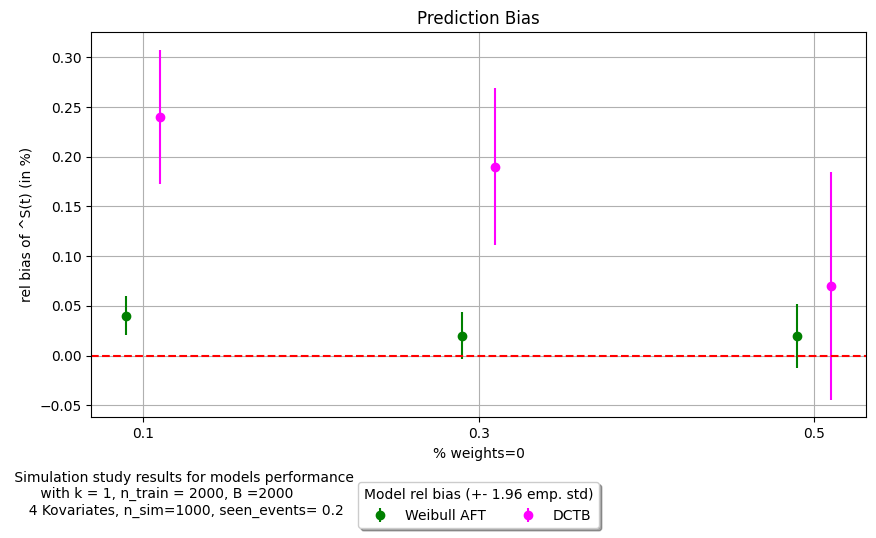

In [7]:
# Plot Prediction Bias
weights_zero = [0.1, 0.3, 0.5]
pred_bias = [ pred_bias_0_1,   pred_bias_0_3,   pred_bias_0_5  ]
errors =    [ pred_error_0_1,  pred_error_0_3,  pred_error_0_5 ]
names = ['Weibull AFT', 'DCTB']

# Erzeuge ein Plot
plt.figure(figsize=(10, 5))
colors = ['green', 'magenta']  # Farben für die verschiedenen Prädiktoren
offset = np.linspace(-0.01, 0.01, len(names))  # Kleinere Versatzwerte für die x-Werte

# Plotten der Punkte mit Fehlerbalken und Legende
for j, name in enumerate(names):
    for i, weight in enumerate(weights_zero):
        plt.errorbar(weight + offset[j], pred_bias[i][j], yerr=errors[i][j]*1.96, fmt='o', color=colors[j], label=name if i == 0 else "")

# Rote Linie bei y = 0 plotten
plt.axhline(y=0, color='red', linestyle='--')

# Achsenbeschriftungen und Titel hinzufügen
plt.xlabel('% weights=0')
plt.ylabel('rel bias of ^S(t) (in %)')
plt.title('Prediction Bias')
plt.grid(True)

# Legende unterhalb des Plots platzieren
plt.legend(title='Model rel bias (+- 1.96 emp. std)', loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=2)

# Nur die gewünschten x-Werte anzeigen
plt.xticks(weights_zero)

# Eigenen Text unterhalb des Plots hinzufügen
plt.text(0.12, -0.2, f" Simulation study results for models performance \n with k = {data_generation_parameter_0_1['shape_weibull']}, n_train = {int(n*0.7)}, B ={B_RF}\
         \n  4 Kovariates, n_sim={n_sim}, seen_events= {np.round(np.mean(portion_seen_events_train),2)} ", 
         ha='center', va='center', transform=plt.gca().transAxes)

# plot speichern 
plt.savefig(path + f'/results/model_bias(n_train){int(n*0.7)}__(B_RF){B_RF}__(events){np.round(np.mean(portion_seen_events_train),2)}.png', bbox_inches='tight')

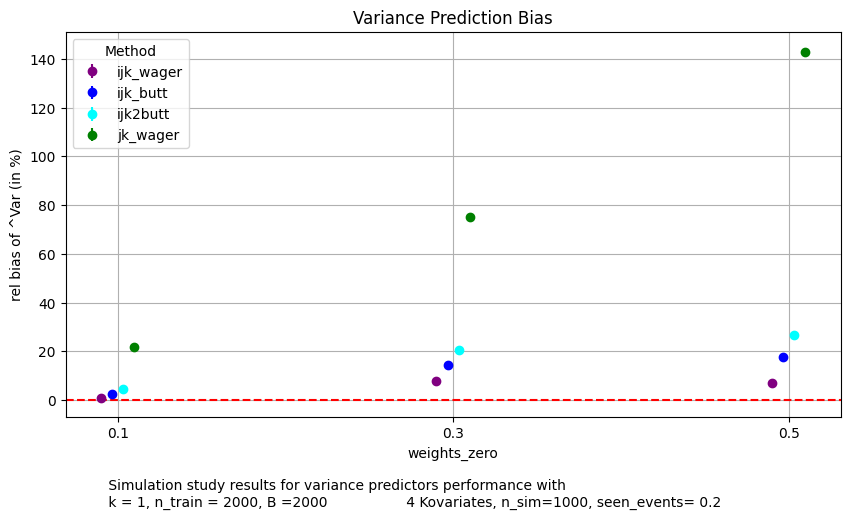

In [8]:
# Plot Variance Prediction Bias
weights_zero = [0.1, 0.3, 0.5]
pred_bias = [
    var_bias_0_1,  # Biaswerte für weights_zero = 0.1
    var_bias_0_3,  # Biaswerte für weights_zero = 0.3
    var_bias_0_5    # Biaswerte für weights_zero = 0.5
]
errors = [
    var_bias_error_0_1 ,  # Fehler für weights_zero = 0.1
    var_bias_error_0_3  ,  # Fehler für weights_zero = 0.3
    var_bias_error_0_5   # Fehler für weights_zero = 0.5
]
names = ['ijk_wager', 'ijk_butt', 'ijk2butt', 'jk_wager']

# Erzeuge ein Plot
plt.figure(figsize=(10, 5))
colors = ['purple', 'blue', 'cyan', 'green']  # Farben für die verschiedenen Prädiktoren
offset = np.linspace(-0.01, 0.01, len(names))  # Kleinere Versatzwerte für die x-Werte

# Plotten der Punkte mit Fehlerbalken und Legende
for j, name in enumerate(names):
    for i, weight in enumerate(weights_zero):
        plt.errorbar(weight + offset[j], pred_bias[i][j], yerr=errors[i][j], fmt='o', color=colors[j], label=name if i == 0 else "")

# Rote Linie bei y = 0 plotten
plt.axhline(y=0, color='red', linestyle='--')

# Achsenbeschriftungen und Titel hinzufügen
plt.xlabel('weights_zero')
plt.ylabel('rel bias of ^Var (in %)')
plt.title('Variance Prediction Bias')
plt.grid(True)
plt.legend(title='Method')

# Nur die gewünschten x-Werte anzeigen
plt.xticks(weights_zero)
plt.text(0.05, -0.2, f" Simulation study results for variance predictors performance with \n k = {data_generation_parameter_0_1['shape_weibull']}, n_train = {int(n*0.7)}, B ={B_RF}\
                  4 Kovariates, n_sim={n_sim}, seen_events= {np.round(np.mean(portion_seen_events_train),2)} ", 
         ha='left', va='center', transform=plt.gca().transAxes)

# plot speichern 
plt.savefig(path + f'/results/var_bias(n_train){int(n*0.7)}__(B_RF){B_RF}__(events){np.round(np.mean(portion_seen_events_train),2)}.png', bbox_inches='tight')